# Estadística descriptiva con Carlos Lesmes y

![logo](julia-logo-color.png)

In [384]:
using Dates
Dates.format(now(), "E, dd U yyyy HH:MM:SS")

"Tuesday, 04 August 2026 12:52:24"

In [385]:
using Plots, StatsPlots, Colors, Random
using StatsBase, Statistics, Distributions, DataFrames
gr()

Plots.GRBackend()

## Definiciones básicas
Los **parámetros** son las medidas que se calculan sobre una población y generalmente se denotan con letras griegas, 

1. media $\mu$
2. varianza $\sigma^2$
3. tamaño $N$, ...

Los **estadísticos** o **estadígrafos** son las medidas que se calculan sobre una muestra y se denotan con letras latinas,

1. media $\bar{X}$
2. varianza $S^2$
3. tamaño $n$, ...

Para los datos de una población utilizaremos $X_1,X_2,\cdots,X_N$ y para una muestra utilizaremos $x_1,x_2,\cdots,x_n$

# Medidas descriptivas

## Medidas de tendencia central

**Definición**: Una medida de tendencia central o promedio para un conjunto de datos cuantitativos es un valor entre el dato mínimo y el dato máximo. Se busca encontrar un buen representante de todos los datos.

## Media aritmética

La media aritmética está dada por: (muestra y población)

$$\bar{X}=M(X)= \frac{1}{n}\sum_{i=1}^{n}x_{i}$$

$$\mu= \frac{1}{N}\sum_{i=1}^{N}X_{i}$$

Para calcular estadísticas descriptivas usamos los paquetes `StatsBase` y `Statistics`.

Creamos un vector y

In [261]:
y = 5 .*rand(10) .+6

10-element Vector{Float64}:
  8.308154320154907
  7.401747793064159
  8.031985991874883
  7.673038059693694
  8.247709940441599
  7.722715880448264
  7.218339721752231
 10.096077480885896
  9.915748049219474
  8.45388357636973

Longitud del vector

In [262]:
length(y)

10

In [263]:
minimum(y) # mínimo

7.218339721752231

In [264]:
maximum(y) # máximo

10.096077480885896

Mínimo y máximo

In [265]:
extrema(y)

(7.218339721752231, 10.096077480885896)

La media aritmética en julia es la función `mean`.

In [266]:
mean(y)

8.306940081390483

In [267]:
2^3

8

Operaciones vectorizadas

In [268]:
2 .^[1,2,3]

3-element Vector{Int64}:
 2
 4
 8

## Mediana

La mediana es un valor que supera el 50% de los datos y es superado por el otro 50%. Para calcular la mediana se deben ordenar los datos y seguir la fórmula a continuación:

$$ Me(X)=
    \begin{cases}
    \text{Si n es par} & \displaystyle\frac{X_{\frac{n}{2}}+X_{\frac{n}{2}+1}}{2} \\
    &\\
    \text{Si n es impar} & \displaystyle X_\frac{n+1}{2}
    \end{cases}
$$

Ordenar

In [269]:
sort(y)

10-element Vector{Float64}:
  7.218339721752231
  7.401747793064159
  7.673038059693694
  7.722715880448264
  8.031985991874883
  8.247709940441599
  8.308154320154907
  8.45388357636973
  9.915748049219474
 10.096077480885896

Mediana

In [270]:
median(y)

8.139847966158241

El 50% de los datos es menor a ...

Gráficos

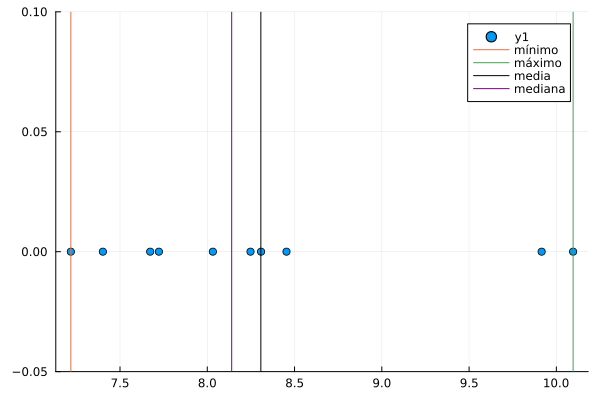

In [271]:
z=zeros(10)
plot(y,z,seriestype=:scatter,ylim=(-0.05,0.1))
plot!([minimum(y)], seriestype="vline", label="mínimo")
plot!([maximum(y)], seriestype="vline", label="máximo")
plot!([mean(y)], seriestype="vline", label="media", color=:black)
plot!([median(y)], seriestype="vline", label="mediana", color=:purple)

## Moda

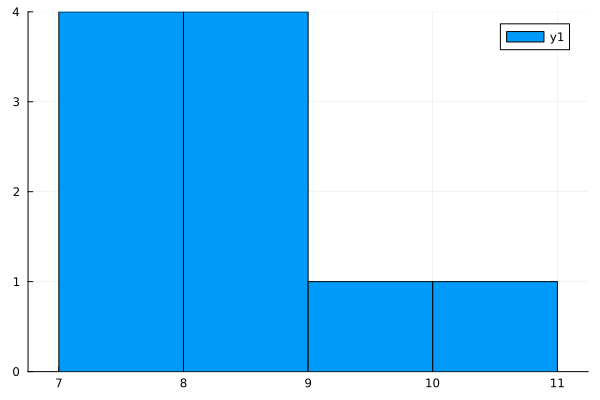

In [272]:
histogram(y)

La moda es el dato que más se repite. Es posible que no haya moda o que haya varias modas.

In [273]:
α = mode(y)

8.308154320154907

Para ver los símbolos que se completan con TAB vea: [simbolos](https://docs.julialang.org/en/v1/manual/unicode-input/)

In [274]:
😂=3

3

## Media geométrica

La media geométrica se utiliza para promediar tasas o índices. No debe calcularse si un dato es cero o negativo.

$$
Mg(X)=\sqrt[n]{X_1X_2 \cdots X_n}=\left(\prod_{1=1}^{n}X_{i}\right)^\frac{1}{n}=10^{M(log(X))}=e^{M(ln(X))}
$$

In [275]:
geomean(y)

8.257915426233767

## Media armónica

Se utiliza para promediar velocidades. No se puede calcular cuando algún dato es cero. Es el inverso de la media de los inversos.

$$
Ma(X)=\frac{1}{\displaystyle\frac{1}{n}\sum_{i=1}^{n}\frac{1}{X_i}}=\frac{1}{M(\frac{1}{X})}
$$

In [276]:
harmmean(y)

8.211850118416569

## Media general de orden p

$$
M_{p}=\left(\frac{1}{n}\sum_{i=1}^{n}X_{i}^{p}\right)^\frac{1}{p}=\left(M(X^p)\right)^{\frac{1}{p}}, p \in \mathbb{R}-\{0\}
$$

### casos especiales

1. Si $p=1$ se genera la media aritmética
2. si $p=-1$ se genera la media armónica
3. si $p \to 0$ se genera la media geométrica
4. si $p=2$ se llama la media cuadrática
5. si $p=3$ se llama media cúbica
6. si $p \to \infty$ el valor se acerca al dato máximo
7. si $p \to -\infty$ el resultado se acerca al dato mínimo

In [277]:
genmean(y,3) 

8.413125409412023

In [278]:
genmean(y,10)

8.821471877006045

In [279]:
genmean(y,-20.8)

7.733514745588952

## Media aritmética ponderada

Sea $\{X_1,X_2,\cdots,X_n\}$ un conjunto de datos y sean $w_1,w_2,\cdots,w_n$ las ponderaciones de los $X_i$ respectivamente entonces la media aritmética de los $X_i$ ponderada por los $w_i$ está dada por:

$$
\bar{X}=M(X)=\displaystyle\frac{\sum_{i=1}^{n}X_iw_i}{\displaystyle\sum_{i=1}^{n}w_i}
$$

Cuando todas las $w_i$ son iguales a 1 se genera la media aritmética.

In [280]:
w = [0.3,0.3,0.4] #ponderación

3-element Vector{Float64}:
 0.3
 0.3
 0.4

In [281]:
nota=[2,3,4]

3-element Vector{Int64}:
 2
 3
 4

In [282]:
mean(nota, weights(w))

3.1

# Medidas de posición

## Percentiles

El percentil k,  $P_k$ deja $k\%$ de los datos a la izquierda $0 \le k \le 100$. 

$$
P_k(X)=
\begin{cases}
 \text{1. Ordenar los datos}  \\
 \text{2. Calcular}\quad i=\displaystyle\frac{kn}{100} \\
 3.
 \begin{cases}
\text{Si i es entero} & \displaystyle\frac{X_i + X_{i+1}}{2}\\
\text{si i no es entero} &  X_{[i]+1}
\end{cases}
\end{cases}
$$
Donde $[i]$ es la parte entera de $i$. O en Julia:

In [283]:
function percent(x,k)
    i = k * length(x)/100
    if i == floor(i)
       i = floor(Int,i)
        return (x[i] + x[i+1])/2
    else 
        return  x[floor(Int,i)+1]
    end
end

percent (generic function with 1 method)

In [284]:
xx1=[1,2,3,4,5,6,7,8,9,10,11,12,13]
percent(xx1,75)

10

Julia tiene las funciones `percentile` y `quantile`, veamos algunos ejemplos:

In [285]:
y1 = rand(Exponential(3),50)

50-element Vector{Float64}:
 4.958812428161778
 8.055855835534258
 0.11881114408808802
 0.6969071587413513
 1.4198384573705625
 4.0539493024182995
 6.846973668450362
 4.329348776390765
 0.21236663737837286
 3.8001871312498277
 ⋮
 6.290386496410193
 2.3885758187433517
 2.8467282255425856
 7.619998891987859
 1.8970084213632425
 2.538338620121786
 2.943964707360575
 3.901581171233052
 1.539891069939346

In [286]:
extrema(y1)

(0.025597825074907266, 9.356219075980476)

In [287]:
P35 = percentile(y1,35)

1.0004691492455495

El 35% de los datos es inferior a .... y el 65% es superior a .....

In [288]:
cuartiles = nquantile(y1,4)

5-element Vector{Float64}:
 0.025597825074907266
 0.6170566522151965
 2.2158606446504594
 3.9378892295179213
 9.356219075980476

Hay tres cuartiles: $Q_1,Q_2$ y $Q_3$. Los cuartiles dividen una distribución en 4 partes, dejando 25% de los datos entre cada uno. El cuartil 1 $Q_1=P_{25}$, cuartil 2 $Q_2=P_{50}$ y el cuartil 3 $Q_3=P_{75}$.

In [289]:
deciles = nquantile(y1,10)

11-element Vector{Float64}:
 0.025597825074907266
 0.18461407373831112
 0.4833155364462468
 0.6951550387685145
 1.4281668648237305
 2.2158606446504594
 2.883190419731614
 3.7259363261261855
 4.109029197212793
 6.34604521361421
 9.356219075980476

Hay 9 deciles $D_1,D_2,\cdots, D_9$ que dejan 10% entre cada uno de ellos.

In [290]:
median(y1)

2.2158606446504594

Seleccionar los datos menores a 5

In [291]:
y1 .< 5

50-element BitVector:
 1
 0
 1
 1
 1
 1
 0
 1
 1
 1
 ⋮
 0
 1
 1
 0
 1
 1
 1
 1
 1

In [292]:
y1[y1 .< 5]

42-element Vector{Float64}:
 4.958812428161778
 0.11881114408808802
 0.6969071587413513
 1.4198384573705625
 4.0539493024182995
 4.329348776390765
 0.21236663737837286
 3.8001871312498277
 2.4483478183018965
 1.0377751528960437
 ⋮
 2.0474934036177395
 0.025597825074907266
 2.3885758187433517
 2.8467282255425856
 1.8970084213632425
 2.538338620121786
 2.943964707360575
 3.901581171233052
 1.539891069939346

La mediana es el mismo percentil 50 y además se tiene $$ Mediana=Q_2=D_5=P_{50} $$

¿Qué porcentaje de datos son menores a 5 en `y1`?

In [293]:
length(y1[y1 .< 5])

42

In [294]:
length(y1[y1 .< 5])/length(y1)*100

84.0

El 74% de los datos es menor a 5

In [295]:
percentile(y1,76)

3.9733829611458047

## Recorrido intercuartílico

$$RIQ=P_{75}-P_{25}=Q_3-Q_1$$

 es el rango del 50% central de los datos.

In [296]:
iqr(y1)

3.320832577302725

Vea los colores con nombre propio [colores](https://juliagraphics.github.io/Colors.jl/stable/namedcolors/)

In [297]:
Colors.color_names

Dict{String, Tuple{Int64, Int64, Int64}} with 666 entries:
  "darkorchid"     => (153, 50, 204)
  "chocolate"      => (210, 105, 30)
  "chocolate2"     => (238, 118, 33)
  "grey69"         => (176, 176, 176)
  "grey97"         => (247, 247, 247)
  "olivedrab3"     => (154, 205, 50)
  "deeppink2"      => (238, 18, 137)
  "mediumpurple2"  => (159, 121, 238)
  "ivory1"         => (255, 255, 240)
  "gray95"         => (242, 242, 242)
  "darkgoldenrod4" => (139, 101, 8)
  "lemonchiffon2"  => (238, 233, 191)
  "palegreen4"     => (84, 139, 84)
  "cornsilk4"      => (139, 136, 120)
  "red1"           => (255, 0, 0)
  "wheat1"         => (255, 231, 186)
  "lightpink4"     => (139, 95, 101)
  "wheat2"         => (238, 216, 174)
  "purple2"        => (145, 44, 238)
  ⋮                => ⋮

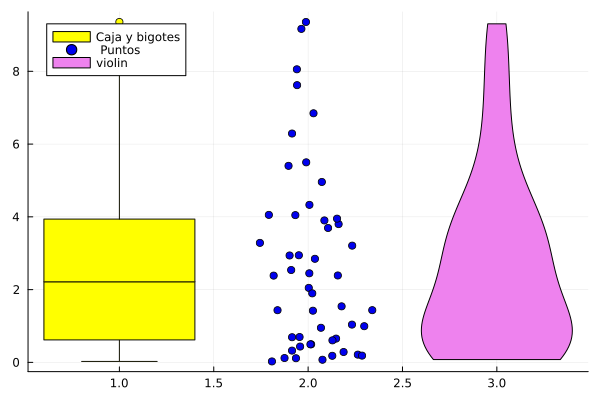

In [298]:
boxplot(y1,label="Caja y bigotes", color=:yellow)
dotplot!(y1, label= " Puntos",color=:blue2)
violin!(y1, label="violin", color=:violet)


El diagrama de caja y bigotes, box and whiskers, sirve para detectar datos atípicos, datos extremos o outliers. Son datos muy grandes o muy pequeños con 
respecto a los demás.

## Bigotes

In [299]:
B1 = percentile(y1,25)-1.5*iqr(y1)

-4.3641922137388915

In [300]:
B2 = percentile(y1,75)+1.5*iqr(y1)

8.91913809547201

El diagrama de caja se utiliza para detectar datos atípicos, datos extremos, también llamados *outliers*. Son datos muy grandes o muy pequeños con respecto a los demás.Los datos por debajo del bigote 1 y por encima del bigote 2 son outliers.

In [301]:
y1[y1.< B1]

Float64[]

In [302]:
y1[y1.>B2]

2-element Vector{Float64}:
 9.356219075980476
 9.166821458218795

Hay .... outliers.

# Medidas de dispersión

Son para determinar qué tan dispersos están los datos.

## Rango

In [303]:
span(y1)

0.025597825074907266:1.0:9.025597825074907

In [304]:
collect(span(y1))

10-element Vector{Float64}:
 0.025597825074907266
 1.0255978250749074
 2.0255978250749074
 3.0255978250749074
 4.025597825074907
 5.025597825074907
 6.025597825074907
 7.025597825074907
 8.025597825074907
 9.025597825074907

## Recorrido intercuartílico

In [305]:
iqr(y1)

3.320832577302725

El 50% central de los datos está en un intervalo de ... unidades

## Varianza

La varianza es el promedio de las distancias al cuadrado de cada dato a la media aritmética. Las fórmulas para muestra y población son diferentes y están dadas por:

$$
S^2=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{X})^{2}
$$

$$
\sigma^2=\frac{1}{N}\sum_{i=1}^{N}(X_i-\mu)^{2}
$$

La varianza tiene las unidades originales de la variable al cuadrado.

In [306]:
var(y1, corrected=true) # muestral

6.267190520359653

In [307]:
var(y1, corrected=false) # poblacional

6.1418467099524605

## Desviación estándar
Es la raiz cuadrada de la varianza. Tiene las unidades originales de la variable. Es lo que se alejan los datos en promedio de la media.

In [308]:
std(y1, corrected = true)

2.5034357432056558

los datos se alejan en promedio de la media en ...

In [309]:
std(y1, corrected = false)

2.478274946399705

## Coeficiente de variación
El coeficiente de variación es el cociente de la desviación estándar sobre la media. Sirve para comparar la dispersión relativa de dos o más distribuciones.

In [310]:
cvy1 = variation(y1)

0.9320704528136143

In [311]:
std(y1)/mean(y1)

0.9320704528136143

La desviación estándar es el ......% de la media. 


In [312]:
cvy=variation(y)

0.11793235768708128

Hay más dispersión relativa en la distribución de ...

## Medidas de forma
## Momentos
El momento de orden $r$ con respecto a la media es:

$$
\mathscr{M}_{r}(X)=\displaystyle\frac{1}{n}\displaystyle\sum_{i=1}^{n}(X_{i}-\bar{X})^{r}, \qquad r=0,1,2,\cdots
$$

Casos especiales:

1. Si $r=0$ entonces  $\mathscr{M}_{0}=1$.
2. Si $r=1$ entonces  $\mathscr{M}_{1}=0$.
2. Si $r=2$ entonces  $\mathscr{M}_{2}=\sigma^2$.

## Coeficiente de sesgo o asimetría 
[sesgo](https://es.wikipedia.org/wiki/Asimetr%C3%ADa_estad%C3%ADstica)

$$
\gamma_1=\displaystyle\frac{\mathscr{M}_{3}(X)}{\sigma^{3}_{X}} 
$$

## Coeficiente de curtosis o apuntamiento
![curtosis](curtosis.png)

$$
\gamma_2=\displaystyle\frac{\mathscr{M}_{4}(X)}{\sigma^{4}_{X}}-3
$$

$\gamma_2$ Es el exceso de curtosis, si es positiva decimos que la distribución es leptocúrtica, si es cero mesocúrtica y si es negativo es platicúrtica

In [313]:
m3=sum((y1.-mean(y1)).^3)/length(y1)

16.007580105258103

In [314]:
moment(y1,0)

1.0

In [315]:
moment(y1,1)

2.708944180085382e-16

In [316]:
moment(y1,2)

6.1418467099524605

In [317]:
moment(y1,3)

16.007580105258103

In [318]:
moment(y1,4)

126.80001644740258

In [319]:
skewness(y1) #sesgo

1.051664524697001

La distribución de y1 tiene sesgo .....

In [320]:
kurtosis(y1)

0.3614090414800093

La distribución de y1 es .....

In [321]:
moment(y1,4)/var(y1,corrected=false)^2-3

0.36140904148000885

## Distribuciones de frecuencia

## Variable cualitativa

In [322]:
using FreqTables

In [323]:
cual=sample(["apple","samsung","huawei"],100)

100-element Vector{String}:
 "apple"
 "huawei"
 "samsung"
 "huawei"
 "apple"
 "samsung"
 "huawei"
 "apple"
 "huawei"
 "huawei"
 ⋮
 "huawei"
 "apple"
 "huawei"
 "apple"
 "huawei"
 "huawei"
 "apple"
 "samsung"
 "samsung"

In [324]:
tabla1=freqtable(cual)

3-element Named Vector{Int64}
Dim1    │ 
────────┼───
apple   │ 36
huawei  │ 40
samsung │ 24

In [325]:
prop(tabla1)

3-element Named Vector{Float64}
Dim1    │ 
────────┼─────
apple   │ 0.36
huawei  │  0.4
samsung │ 0.24

In [326]:
Vector(tabla1)

3-element Vector{Int64}:
 36
 40
 24

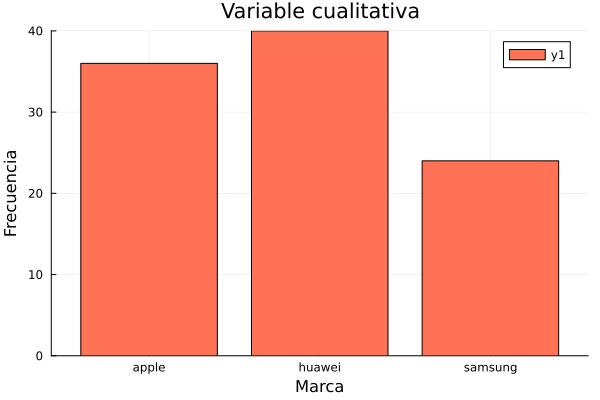

In [327]:
g1 = bar(unique(cual),Vector(tabla1),title="Variable cualitativa", ylabel="Frecuencia",color=:coral1,xlabel="Marca")

## Variable discreta

In [328]:
discr=rand(Poisson(4), 50)

50-element Vector{Int64}:
 4
 3
 4
 2
 3
 2
 2
 3
 3
 3
 ⋮
 3
 4
 1
 4
 3
 1
 6
 7
 6

In [329]:
unique(discr)

9-element Vector{Int64}:
  4
  3
  2
  8
  5
  6
  1
 10
  7

In [330]:
tabla2=freqtable(discr)

9-element Named Vector{Int64}
Dim1  │ 
──────┼───
1     │  5
2     │  8
3     │ 15
4     │  7
5     │  6
6     │  6
7     │  1
8     │  1
10    │  1

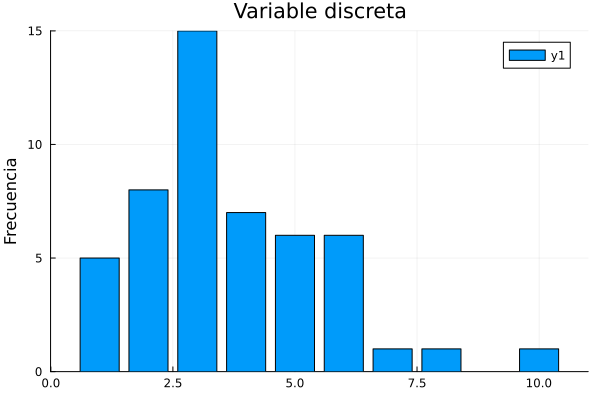

In [331]:
bar(sort(unique(discr)),Vector(tabla2),title="Variable discreta",ylabel="Frecuencia")

## Variable continua

In [332]:
extrema(y1)

(0.025597825074907266, 9.356219075980476)

In [333]:
using CategoricalArrays

In [334]:
freqtable(cut(y1, [0, 5,10,15,20],labels=["0 a 5", "5 a 10", "10 a 15", "15 a 20" ]))

4-element Named Vector{Int64}
Dim1    │ 
────────┼───
0 a 5   │ 42
5 a 10  │  8
10 a 15 │  0
15 a 20 │  0

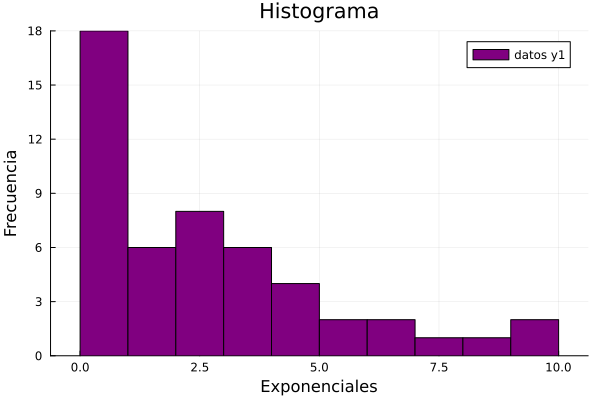

In [335]:
histogram(y1, title="Histograma", xlabel="Exponenciales",ylabel="Frecuencia", color=:purple,
    bins=10,label="datos y1")

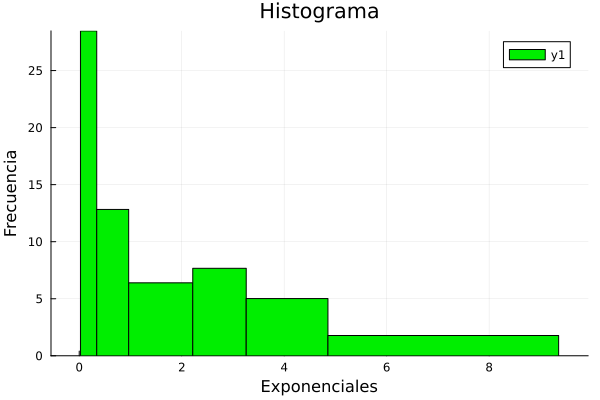

In [336]:
ea_histogram(y1,color=:green2,title="Histograma", xlabel="Exponenciales",ylabel="Frecuencia") # equal area

### Otras funciones de descriptiva en Julia

In [337]:
mean_and_var(y1)

(2.685886818586091, 6.267190520359653)

In [338]:
mean_and_std(y1)

(2.685886818586091, 2.5034357432056558)

### Datos estandarizados

Se resta la media y se divide por la desviación estándar

In [339]:
z = zscore(y1)

50-element Vector{Float64}:
  0.9079224884219318
  2.145039684570417
 -1.0254210364556255
 -0.7944999847680716
 -0.505724328915409
  0.546473975833069
  1.6621504510980531
  0.6564825808950931
 -0.9880501977815372
  0.44510841378212185
  ⋮
  1.4398211288652973
 -0.11876118676089195
  0.06424826656446829
  1.9709361771289668
 -0.3151182926759237
 -0.05893828066678043
  0.10308947991771282
  0.4856103680497353
 -0.45776918850702936

Puntaje z o estandarización: a cada dato se le resta la media y a este resultado se lo divide por la desviación estándar

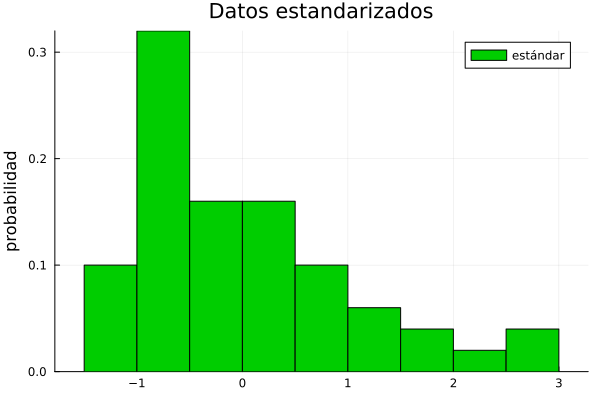

In [340]:
histogram(z, title="Datos estandarizados", ylabel="probabilidad", norm=:probability, 
    bins=10, label="estándar",color=:green3)

In [341]:
summarystats(y1)

Summary Stats:
Length:         50
Missing Count:  0
Mean:           2.685887
Std. Deviation: 2.503436
Minimum:        0.025598
1st Quartile:   0.617057
Median:         2.215861
3rd Quartile:   3.937889
Maximum:        9.356219


In [342]:
describe(y1)

Summary Stats:
Length:         50
Missing Count:  0
Mean:           2.685887
Std. Deviation: 2.503436
Minimum:        0.025598
1st Quartile:   0.617057
Median:         2.215861
3rd Quartile:   3.937889
Maximum:        9.356219
Type:           Float64


In [343]:
versioninfo()

Julia Version 1.12.6
Commit 15346901f00 (2026-04-09 19:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: macOS (arm64-apple-darwin24.0.0)
  CPU: 8 × Apple M1
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, apple-m1)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 4 virtual cores)
Environment:
  DYLD_FALLBACK_LIBRARY_PATH = /Users/carloslesmes/.julia/artifacts/c1600fa286afe4bf3616780a19b65285c63968ca/lib:/Users/carloslesmes/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/lib/julia:/Users/carloslesmes/.julia/artifacts/b820a0a437e8501d06a17439abd84feaa5b6cca3/lib:/Users/carloslesmes/.julia/artifacts/ccab86a3f5c2e11b743d3c30a624a3a95c3dc170/lib:/Users/carloslesmes/.julia/artifacts/a313d7c1b6344b380ad5425226ece4d3952012c3/lib:/Users/carloslesmes/.julia/artifacts/d3c452363ecbfffb1b5e29644395f7016c0ec781/lib:/Users/carloslesmes/.julia/artifacts/21209a2ac399ce693d73daf1aa8d670fbc84d70f/lib:/Users

## Escribir datos a Excel

In [344]:
Random.seed!(123) # genera los mismos siempre los mismos aleatorios
datos=rand(Poisson(5),100).+1;

In [345]:
using XLSX

In [346]:
 XLSX.openxlsx("datos.xlsx",mode="w") do xf
       sheet = xf[1]
       XLSX.rename!(sheet, "uno") 
       sheet["A1", dim=1] = datos
       end

100-element Vector{Int64}:
  6
  8
  8
  8
 10
  2
  6
  5
  3
  3
  ⋮
  6
  6
  7
  2
 11
  3
  2
  5
  4

# Percentiles

In [347]:
xper=[3310,3355,3450,3480,3480,3490,3520,3540,3550,3650,3730,3925]


12-element Vector{Int64}:
 3310
 3355
 3450
 3480
 3480
 3490
 3520
 3540
 3550
 3650
 3730
 3925

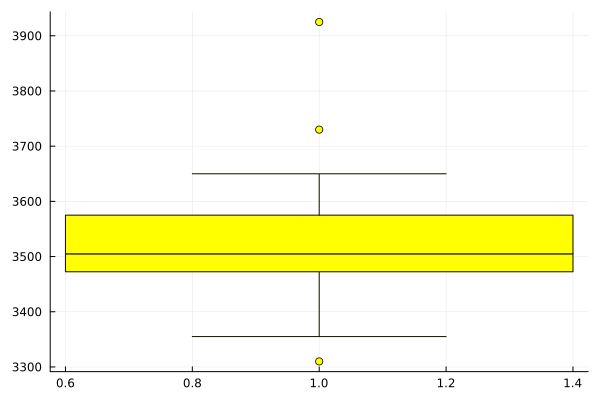

In [348]:
plot(xper, st=:boxplot, color=:yellow, leg=false)

In [349]:
Qxper = nquantile(xper,4)

5-element Vector{Float64}:
 3310.0
 3472.5
 3505.0
 3575.0
 3925.0

In [350]:
yp=[1,2,3,4,5]
quantile(yp, .75, alpha=0.5,beta=.5)

4.25

In [351]:
percent(xper,25)

3465.0

In [352]:
percent(xper,50)

3505.0

In [353]:
percent(xper,75)

3600.0

In [354]:
mean(xper)

3540.0

In [355]:
mode(xper)

3480

In [356]:
riq=3600-3465

135

In [357]:
b1=3465-1.5*riq

3262.5

In [358]:
b2=3600+1.5*riq

3802.5

In [359]:
xper[xper .> b2]

1-element Vector{Int64}:
 3925

In [360]:
xper[xper.< b1]

Int64[]

In [361]:
extrema(xper)

(3310, 3925)

In [362]:
3925-3310

615

In [363]:
std(xper)

165.65297791138283

In [364]:
std(xper, corrected=false)

158.60065153291984

In [365]:
variation(xper)

0.04679462652863922

In [366]:
std(xper)/mean(xper)*100

4.679462652863922

# Traer datos de excel

In [367]:
xf = XLSX.readxlsx("datos1.xlsx")

XLSX.XLSXError: XLSXError: File datos1.xlsx not found.

In [368]:
using DataFrames

In [369]:
df2= DataFrame(XLSX.readdata("datos1.xlsx","uno","A1:D11"), :auto)
#df2=convert.(Float64,df2[:,:])

XLSX.XLSXError: XLSXError: File datos1.xlsx not found.

In [370]:
eltype(df2)

UndefVarError: UndefVarError: `df2` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

# Estadística descriptiva multivariada

In [371]:
x1=rand(100,5) 

100×5 Matrix{Float64}:
 0.749267   0.706417   0.561611   0.660407    0.6796
 0.694796   0.559878   0.683877   0.0533612   0.500769
 0.214909   0.981865   0.0900279  0.231283    0.013967
 0.727596   0.643874   0.17689    0.963518    0.938535
 0.306806   0.185099   0.182632   0.0184746   0.420604
 0.575203   0.158975   0.123352   0.930599    0.869348
 0.124773   0.524171   0.427991   0.528574    0.292359
 0.79823    0.565744   0.589077   0.101046    0.180341
 0.329642   0.0193543  0.608761   0.128156    0.78709
 0.0609071  0.789934   0.820033   0.169481    0.742799
 ⋮                                            
 0.357044   0.513057   0.701588   0.314214    0.327287
 0.158992   0.754889   0.130506   0.736748    0.0217019
 0.857498   0.477447   0.0912515  0.409883    0.542834
 0.627814   0.0165613  0.203067   0.0867241   0.643166
 0.623      0.237786   0.78315    0.00666333  0.0291392
 0.581748   0.819928   0.358423   0.262773    0.107324
 0.645795   0.0446036  0.098717   0.746301    0.442

In [372]:
df = DataFrame(x1, :auto)

Row,x1,x2,x3,x4,x5
,Float64,Float64,Float64,Float64,Float64
1,0.749267,0.706417,0.561611,0.660407,0.6796
2,0.694796,0.559878,0.683877,0.0533612,0.500769
3,0.214909,0.981865,0.0900279,0.231283,0.013967
4,0.727596,0.643874,0.17689,0.963518,0.938535
5,0.306806,0.185099,0.182632,0.0184746,0.420604
6,0.575203,0.158975,0.123352,0.930599,0.869348
7,0.124773,0.524171,0.427991,0.528574,0.292359
8,0.79823,0.565744,0.589077,0.101046,0.180341
9,0.329642,0.0193543,0.608761,0.128156,0.78709


In [373]:
describe(df, :mean, :std,:q25,:median,:q75)

Row,variable,mean,std,q25,median,q75
,Symbol,Float64,Float64,Float64,Float64,Float64
1,x1,0.554689,0.270087,0.389578,0.601318,0.755072
2,x2,0.482808,0.285043,0.239059,0.463705,0.732826
3,x3,0.508749,0.315131,0.211055,0.501797,0.797155
4,x4,0.453129,0.291434,0.22015,0.453887,0.691256
5,x5,0.520336,0.286054,0.270695,0.542978,0.737678


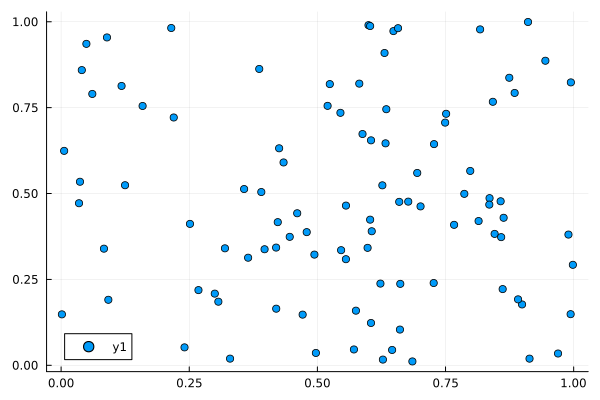

In [374]:
@df df scatter(:x1, :x2)

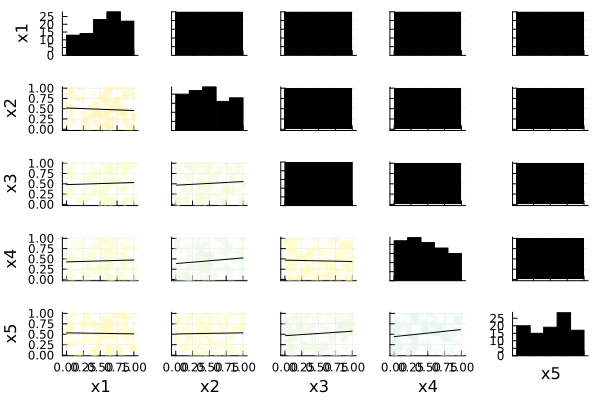

In [375]:
@df df corrplot(cols(1:5), grid = true)

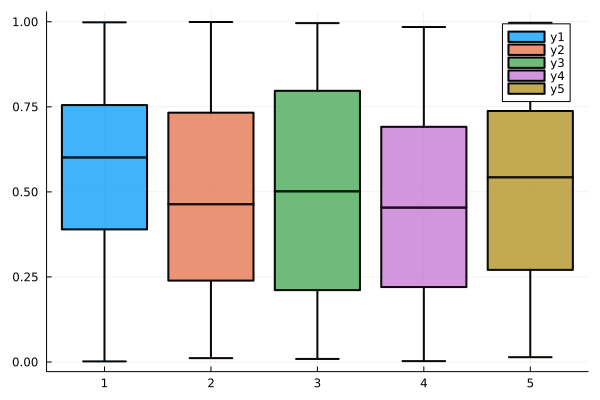

In [376]:
@df df boxplot([:x1,:x2,:x3,:x4,:x5], fillalpha=0.75, linewidth=2)

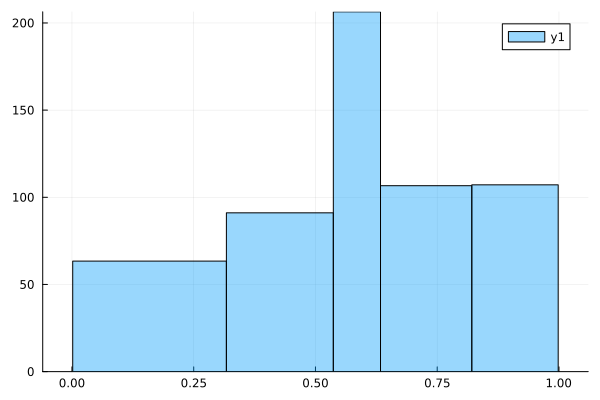

In [377]:
ea_histogram(df.x1, bins = :scott, fillalpha = 0.4)

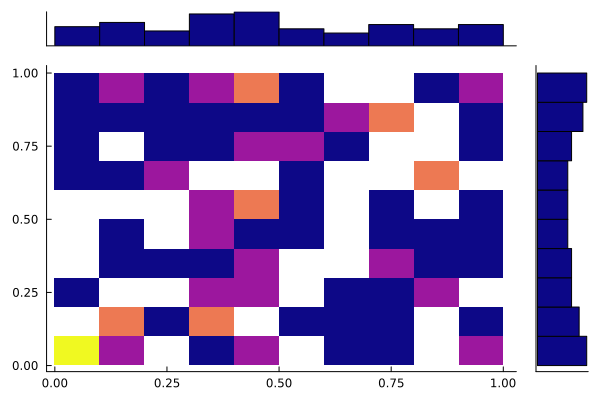

In [378]:
@df df marginalhist(:x2, :x3,bins=10,fc=:plasma)

Filtrar una columna

In [379]:
col2=df[!,2]

100-element Vector{Float64}:
 0.7064170183016768
 0.559878221276493
 0.9818645716217669
 0.6438743342569436
 0.18509873382580666
 0.158975205377063
 0.5241708944943112
 0.5657435234622031
 0.01935430348985434
 0.789934312550799
 ⋮
 0.513056738784237
 0.7548886244273155
 0.47744737925019476
 0.016561301774274395
 0.2377863186340553
 0.8199283070235536
 0.044603624468407266
 0.4425415267210636
 0.8593120155063136

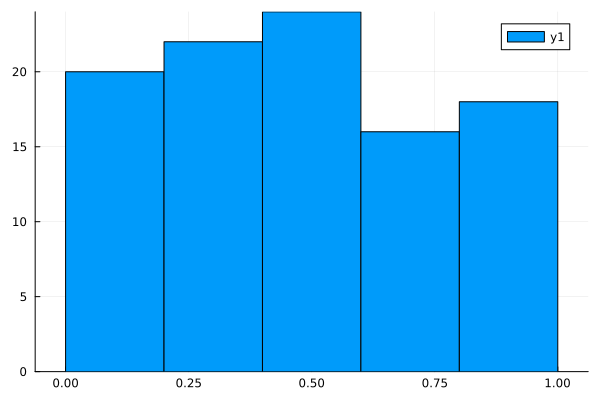

In [380]:
histogram(col2)

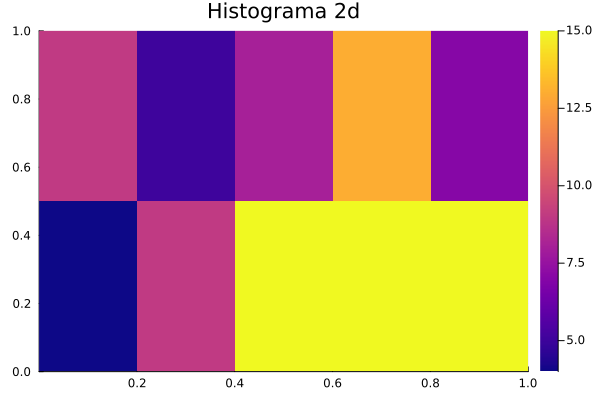

In [381]:
histogram2d(df.x1, df.x2, color=:plasma, title="Histograma 2d")

# Leer archivos .csv

In [382]:
using CSV
datos = CSV.read("beer_test.csv", DataFrame)

ArgumentError: ArgumentError: "beer_test.csv" is not a valid file or doesn't exist

In [383]:
using RDatasets
iris = dataset("datasets", "iris")
describe(iris)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,SepalLength,5.84333,4.3,5.8,7.9,0,Float64
2,SepalWidth,3.05733,2.0,3.0,4.4,0,Float64
3,PetalLength,3.758,1.0,4.35,6.9,0,Float64
4,PetalWidth,1.19933,0.1,1.3,2.5,0,Float64
5,Species,,setosa,,virginica,0,"CategoricalValue{String, UInt8}"
